In [1]:
# Import the pandas library and give it the short name 'pd'
# Pandas is the main tool for working with tabular data in Python.
import pandas as pd


# Read the CSV file and store it in a DataFrame called 'df'
# A DataFrame is like an Excel spreadsheet inside Python.
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")


# Display the first 5 rows of the dataset
# Useful for getting a quick look at the data structure.
df.head()


# Show the number of rows and columns
# Output format: (number_of_rows, number_of_columns)
df.shape


# Show all column names
# Helps us understand what variables are available.
df.columns


# Display information about the dataset:
# - number of rows
# - column names
# - data types
# - missing values
df.info()


# Show all unique values in the TotalCharges column
# Useful for checking whether the column contains unexpected values.
df["TotalCharges"].unique()


# Try converting TotalCharges to numbers.
# Any value that cannot be converted becomes NaN.
# Then select the rows where conversion failed.
#
# errors="coerce" means:
# "If conversion fails, replace the value with NaN."
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]


# Select rows where TotalCharges is exactly one space character.
# We suspect some missing values are stored as blank spaces.
df[df["TotalCharges"] == " "]


# Remove leading/trailing spaces and check whether the result is empty.
#
# Example:
# "   " -> ""
#
# This is more robust than checking for exactly one space.
df[df["TotalCharges"].str.strip() == ""]


# Count how many rows have an empty TotalCharges value.
df[df["TotalCharges"].str.strip() == ""].shape


# Remove rows where TotalCharges is empty.
#
# We keep only rows where TotalCharges contains real data.
df = df[df["TotalCharges"].str.strip() != ""]


# Convert TotalCharges from text (string) to numeric values.
#
# Machine learning models need numbers, not text.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])


# Check the dataset information again.
#
# We want to verify that TotalCharges is now numeric.
df.info()


# Count missing values in every column.
#
# A result of 0 means no missing values.
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [2]:
df["Churn"].value_counts()
# Calculate the fraction of each class
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [3]:
# Summary statistics of numerical columns
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [4]:
# Average tenure grouped by churn status
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

/Users/fatemeh/Documents/customer-churn-ml/venv/bin/python


Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


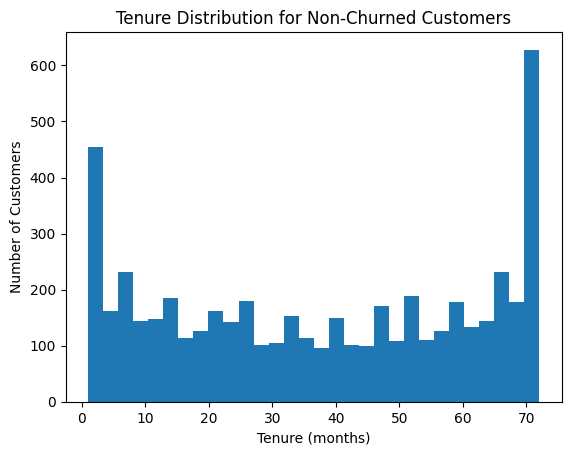

In [5]:
# Print the Python executable currently used by the notebook
import sys

print(sys.executable)

import matplotlib.pyplot as plt

# Select tenure values for customers who stayed
tenure_no = df[df["Churn"] == "No"]["tenure"]

# Create histogram
plt.hist(tenure_no, bins=30)

plt.title("Tenure Distribution for Non-Churned Customers")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")

plt.show()

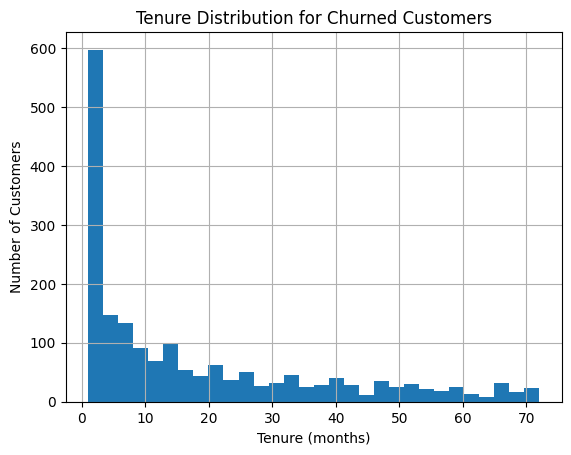

In [6]:
df[df["Churn"] == "Yes"]["tenure"].hist(bins=30)

plt.title("Tenure Distribution for Churned Customers")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
# Divide tenure into bins
pd.cut(df["tenure"], bins=[0,12,24,36,48,60,72]).value_counts().sort_index()

tenure
(0, 12]     2175
(12, 24]    1024
(24, 36]     832
(36, 48]     762
(48, 60]     832
(60, 72]    1407
Name: count, dtype: int64

In [10]:
# Convert target variable to numeric values
# No  -> 0
# Yes -> 1
df["Churn_num"] = df["Churn"].map({"No": 0, "Yes": 1})


In [11]:
# Compute average churn rate in each tenure interval
df.groupby(pd.cut(df["tenure"], bins=[0,12,24,36,48,60,72]))["Churn_num"].mean()

/var/folders/7_/9sy813g175v2qht_4818h5x00000gn/T/ipykernel_11392/1902071382.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["tenure"], bins=[0,12,24,36,48,60,72]))["Churn_num"].mean()


tenure
(0, 12]     0.476782
(12, 24]    0.287109
(24, 36]    0.216346
(36, 48]    0.190289
(48, 60]    0.144231
(60, 72]    0.066098
Name: Churn_num, dtype: float64

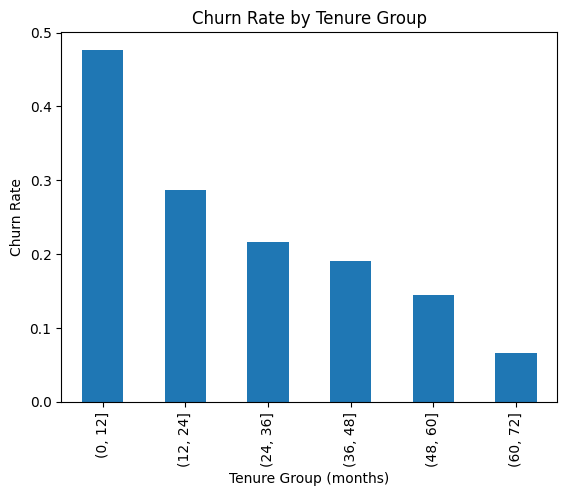

In [12]:
# Compute churn rate by tenure group
churn_by_tenure = df.groupby(
    pd.cut(df["tenure"], bins=[0,12,24,36,48,60,72]),
    observed=False
)["Churn_num"].mean()

# Create a bar chart
churn_by_tenure.plot(kind="bar")

# Add title
plt.title("Churn Rate by Tenure Group")

# Label axes
plt.xlabel("Tenure Group (months)")
plt.ylabel("Churn Rate")

# Display chart
plt.show()

In [13]:
# Average monthly charge for each churn group
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [14]:
# Create groups based on monthly charges
df.groupby(
    pd.cut(df["MonthlyCharges"], bins=[0,30,50,70,90,120]),
    observed=False
)["Churn_num"].mean()

MonthlyCharges
(0, 30]      0.098361
(30, 50]     0.308050
(50, 70]     0.208117
(70, 90]     0.378393
(90, 120]    0.327775
Name: Churn_num, dtype: float64

In [ ]:
## Findings

#1. Customers with short tenure have significantly higher churn rates.
#2. Churn decreases steadily as tenure increases.
#3. Customers with higher monthly charges tend to churn more often, but the relationship is not strictly increasing.
#4. Tenure appears to be one of the strongest predictors of churn.

In [16]:
# Count how many customers belong to each contract type
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [17]:
# Compute the proportion of customers in each contract type
df["Contract"].value_counts(normalize=True)

Contract
Month-to-month    0.551052
Two year          0.239619
One year          0.209329
Name: proportion, dtype: float64

In [18]:
# Compute churn rate for each contract type
df.groupby("Contract")["Churn_num"].mean()

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn_num, dtype: float64

In [19]:
# Compute churn rate by internet service type
df.groupby("InternetService")["Churn_num"].mean()

InternetService
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn_num, dtype: float64

In [ ]:
## Key Findings

#1. Churn decreases strongly as tenure increases.
#2. Month-to-month contracts have much higher churn rates than one- or two-year contracts.
#3. Fiber optic customers exhibit the highest churn rate.
#4. Customers with higher monthly charges tend to churn more frequently.

In [ ]:
# Machine Learning Preparation

In [22]:
# Create a copy of the dataframe
# This protects the original data from accidental modifications
df_ml = df.copy()

# Display the first rows
df_ml.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [23]:
# Convert the target variable into numbers
# No  -> 0
# Yes -> 1
df_ml["Churn"] = df_ml["Churn"].map({"No": 0, "Yes": 1})

# Check that the conversion worked
df_ml["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [24]:
# Create feature matrix X

X = df_ml.drop("Churn", axis=1)
# we remove churn because that is y and it causes data leakage. Information that would not be available at prediction time accidentally leaks into the model.

# Create target vector y
y = df_ml["Churn"]

# Display shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 21)
y shape: (7032,)


In [25]:
X.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn_num             int64
dtype: object

In [26]:
# Remove columns that should not be used as features
X = X.drop(["customerID", "Churn_num"], axis=1)

# Check the new shape
X.shape

(7032, 19)

In [29]:
# Convert categorical variables into dummy variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Check the shape
print(X_encoded.shape)

# Display first rows
X_encoded.head()
X_encoded.shape

(7032, 30)


(7032, 30)

In [28]:
(7032, 30)

(7032, 30)

In [30]:
# Import train-test split utility
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,   # Features
    y,           # Target
    test_size=0.2,      # 20% test data
    random_state=42,    # Reproducible results
    stratify=y          # Preserve churn proportions
)

# Display shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


In [32]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)

/Users/fatemeh/Documents/customer-churn-ml/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [33]:
model

LogisticRegression(max_iter=1000)

In [34]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Show first 10 predictions
y_pred[:10]


array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [35]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [36]:
# accuraccy
# Import evaluation metric
from sklearn.metrics import accuracy_score

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8017057569296375


In [37]:
#confusion matrix
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [162 212]]


In [38]:
# Import classification metrics
from sklearn.metrics import classification_report

# Print evaluation report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [40]:
# Recall: Of all the customers who actually churned, how many did we catch?
# Precesion: Of all the customers who actually churned, how many did we catch?

# In recall, you just say how many you found correct. In precesion you say for what you found correct, which one truely matches with the data set and are truely correct.

In [41]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)

In [42]:
from sklearn.metrics import classification_report

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [44]:
# Import scaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [45]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create model
lr_scaled = LogisticRegression(max_iter=1000)

# Train model
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [46]:
# Predict on scaled test data
scaled_pred = lr_scaled.predict(X_test_scaled)

In [47]:
# Evaluation report
from sklearn.metrics import classification_report

print(classification_report(y_test, scaled_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [48]:
# Get churn probabilities
churn_prob = lr_scaled.predict_proba(X_test_scaled)

# Display first five customers
churn_prob[:5]

array([[0.98288505, 0.01711495],
       [0.40386821, 0.59613179],
       [0.99523568, 0.00476432],
       [0.79995592, 0.20004408],
       [0.89977795, 0.10022205]])

In [49]:
# Probability of churn only
churn_prob = lr_scaled.predict_proba(X_test_scaled)[:, 1]

# Use a lower threshold
pred_03 = (churn_prob >= 0.3).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, pred_03))

              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.76      1407

